In [2]:
import pandas as pd

df = pd.read_csv("../Data/Historical Product Demand.csv")


In [3]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


In [5]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [6]:
df.describe()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
count,1048575,1048575,1048575,1037336,1048575
unique,2160,4,33,1729,3828
top,Product_1359,Whse_J,Category_019,2013/9/27,1000
freq,16936,764447,481099,2075,112682


In [7]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [8]:
df.sample(5)

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
847759,Product_1069,Whse_S,Category_020,2015/8/13,1400
536994,Product_1459,Whse_J,Category_019,2014/7/1,4000
741650,Product_1859,Whse_J,Category_001,2015/4/9,2
702493,Product_1359,Whse_J,Category_019,2015/12/8,300000
894872,Product_1424,Whse_A,Category_019,NaN,4000


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 926152 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      926152 non-null  object        
 1   Warehouse         926152 non-null  object        
 2   Product_Category  926152 non-null  object        
 3   Date              924272 non-null  datetime64[ns]
 4   Order_Demand      926152 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 42.4+ MB


In [11]:
df['Order_Demand'] = pd.to_numeric(df['Order_Demand'], errors='coerce')

print("NaN in Order_Demand" , df["Order_Demand"].isnull().sum())
print("NaN in Date" , df["Date"].isnull().sum())

NaN in Order_Demand 6798
NaN in Date 1880


In [12]:
df.dropna(subset=['Date'], inplace=True)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 924272 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      924272 non-null  object        
 1   Warehouse         924272 non-null  object        
 2   Product_Category  924272 non-null  object        
 3   Date              924272 non-null  datetime64[ns]
 4   Order_Demand      918468 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 42.3+ MB


In [14]:
# รีเซ็ต Index ให้เรียงลำดับใหม่ตั้งแต่ 0 อย่างสวยงาม
df.reset_index(drop=True, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924272 entries, 0 to 924271
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      924272 non-null  object        
 1   Warehouse         924272 non-null  object        
 2   Product_Category  924272 non-null  object        
 3   Date              924272 non-null  datetime64[ns]
 4   Order_Demand      918468 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 35.3+ MB


In [16]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek # 0=จันทร์, 6=อาทิตย์

In [17]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Year,Month,DayOfWeek
0,Product_0993,Whse_J,Category_028,2012-07-27,100.0,2012,7,4
1,Product_0979,Whse_J,Category_028,2012-01-19,500.0,2012,1,3
2,Product_0979,Whse_J,Category_028,2012-02-03,500.0,2012,2,4
3,Product_0979,Whse_J,Category_028,2012-02-09,500.0,2012,2,3
4,Product_0979,Whse_J,Category_028,2012-03-02,500.0,2012,3,4


In [18]:
df['Order_Demand'].describe()

count    9.184680e+05
mean     5.135949e+03
std      3.050339e+04
min      0.000000e+00
25%      2.000000e+01
50%      3.000000e+02
75%      2.000000e+03
max      4.000000e+06
Name: Order_Demand, dtype: float64

สรุปสิ่งที่พบจากข้อมูล:
- mean(5135) and median(300) ต่างกันเยอะมาก ลูกค้าส่วนใหญ่สั่งแค่ไม่เกิน 300 ชิ้น แต่มีลูกค้าลาบใหญ่สั่ง 4000000 ดึง mean ทำให้ mean เชื่อไม่ได้

- outliers Max(4,000,000) ห่างจาก Median(300) ถ้าเอาไป Train Model เลย Model เพี้ยน

- std สูง  std(30,503) สูงกว่า mean(5135) หลายเท่าตัว ยอดสั่งซื้อในแต่ละวัน "ไม่นิ่งเลย"

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

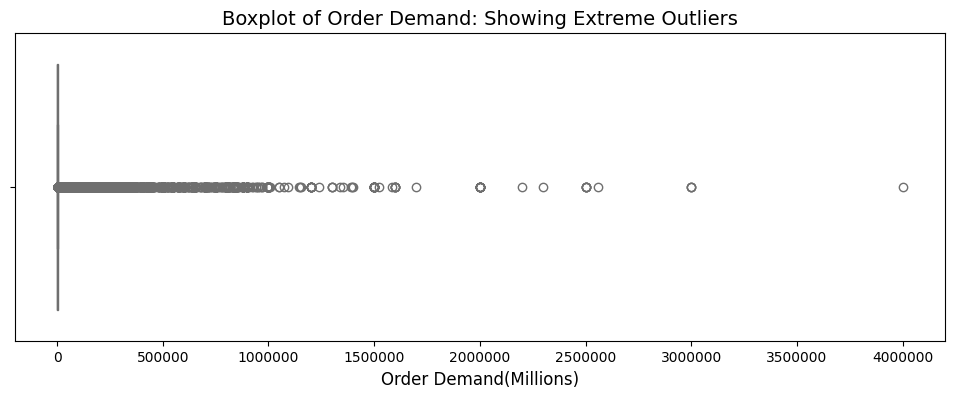

In [23]:
plt.figure(figsize=(12,4))
sns.boxplot(x=df['Order_Demand'], color='skyblue')

plt.title('Boxplot of Order Demand: Showing Extreme Outliers', fontsize=14)
plt.xlabel('Order Demand(Millions)', fontsize=12)

# ปรับฟอร์แมตแกน X ไม่ให้เป็นตัวเลขวิทยาศาสตร์ (e) เพื่อให้ดูง่ายขึ้น
plt.ticklabel_format(style='plain', axis='x')
plt.show()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Gl

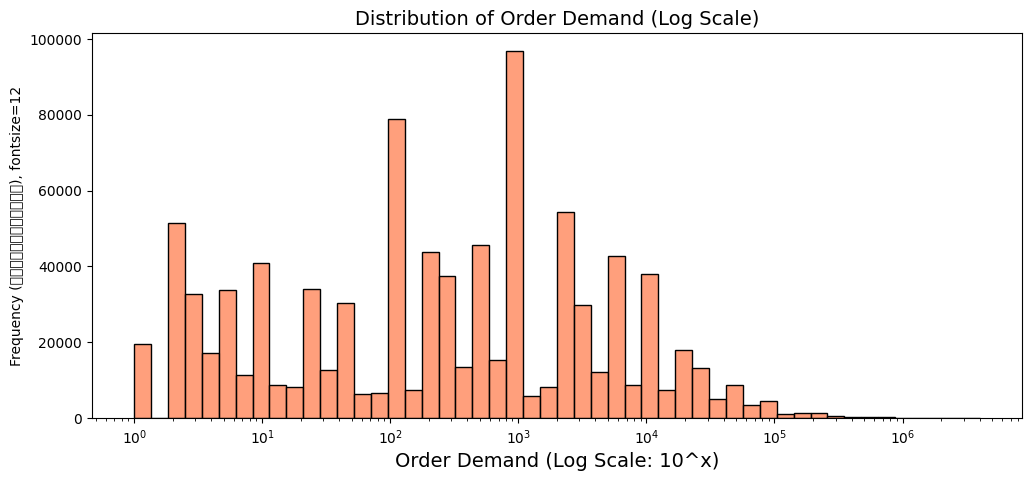

In [25]:
plt.figure(figsize=(12,5))

# เราบวก 1 เข้าไปตอนทำ Log เพื่อป้องกัน Error จากกรณีออเดอร์เป็น 0 (log(0) หาค่าไม่ได้)
sns.histplot(df['Order_Demand'] + 1, bins=50, log_scale=True, color='coral')

plt.title('Distribution of Order Demand (Log Scale)', fontsize=14)
plt.xlabel("Order Demand (Log Scale: 10^x)", fontsize=14)
plt.ylabel('Frequency (จำนวนออเดอร์), fontsize=12')
plt.show()

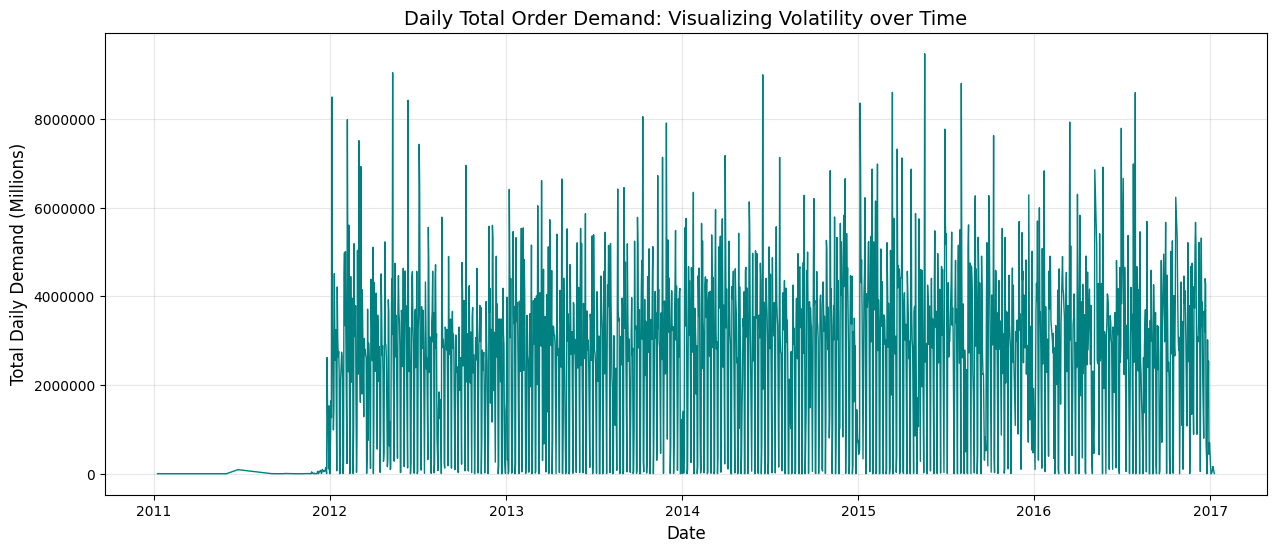

In [26]:
#line chart

daily_demand = df.groupby('Date')['Order_Demand'].sum().reset_index()

plt.figure(figsize=(15,6))
plt.plot(daily_demand['Date'], daily_demand['Order_Demand'], color='teal', linewidth=1)

plt.title('Daily Total Order Demand: Visualizing Volatility over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Daily Demand (Millions)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y') 
plt.grid(True, alpha=0.3)
plt.show()